# Práctica 3 PVC
### Natalia Martínez García y Lucía Vega Navarrete - Grupo 1.1

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
from skimage import io
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import binary_opening, binary_closing, disk, remove_small_objects, remove_small_holes
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter, sobel
from skimage.filters import frangi

In [2]:
# Fijamos la semilla para poder reproducir los resultados
import random
seed = 123
np.random.seed(seed)
random.seed(seed)

## Ejercicio 1 -  Segmentación de carreteras en imagen aérea de alta resolución

### Carga del dataset

Primero cargamos todas las imágenes de satélite y sus máscaras correspondientes desde las carpetas del dataset. Para garantizar que cada imagen está emparejada con su máscara correcta, primero se listan y ordenan los archivos. Después, las imágenes se leen tal cual y las máscaras se binarizan para obtener valores 0/1. Luego, todo se convierte en arrays NumPy para poder procesarlo de forma eficiente en los siguientes pasos de la práctica. Por último, imprimimos las dimensiones de las imágenes para comprobar que todo se ha cargado correctamente. 

In [3]:
# Ruta al dataset
# Lo tenemos en la misma carpeta que el notebook
dataset_path = Path("DataSet_1/roads")
sat_path = dataset_path / "sat" # Carpeta con las imagenes por satelite (inputs del modelo)
gt_path = dataset_path / "gt" # Carpeta con las carreteras marcadas (salidas esperadas)

# Cargar las imágenes
# Las ordenamos para que cada imagen de la carpeta sat este en la misma posicion que en la carpeta gt (tienen el mismo nombre)
sat_files = sorted(sat_path.glob("*.tif*")) # Leer todas las de la carpeta a la vez
gt_files = sorted(gt_path.glob("*.tif*"))

# Listas donde almacenamos las imágenes y sus máscaras ya cargadas
images = []
masks = []

# Recorremos ambas listas en parallelo
for sat_file, gt_file in zip(sat_files, gt_files):
    # Cargar imagen RGB del satelite
    img = io.imread(sat_file)
    images.append(img)
    
    # Cargar y preparar la máscara
    mask = io.imread(gt_file) # La máscara suele venir en escala de grises con valores 0 (fondo) y 255 (carretera)
    mask = (mask > 128).astype(np.uint8) # Lo tenemos que poner convertir a binario (0 y 1) porque ahora tiene como valores 0 y 255
    masks.append(mask)
    
# Convertimos las listas a arrays numpy para poder indexarlas 
images = np.array(images)
masks = np.array(masks)

# Comprobamos las dimensiones
print(f"Shape imágenes: {images.shape}")
print(f"Shape máscaras: {masks.shape}")

Shape imágenes: (20, 1500, 1500, 3)
Shape máscaras: (20, 1500, 1500)


La salida confirma que el dataset se ha cargado correctamente: tenemos 20 imágenes y 20 máscaras, todas con un tamaño uniforme de 1500×1500 píxeles. Las imágenes son RGB (por eso tienen 3 canales) y las máscaras están en formato binario de una sola capa. Esto indica que el procesamiento previo funcionó como se esperaba y que los datos están listos para continuar con el preprocesado y el diseño del método de segmentación.

### División de los datos

Aquí hacemos una división aleatoria del dataset en entrenamiento, validación y test. Para ello, primero generamos una permutación aleatoria de los índices de todas las imágenes, asegurando que la selección no siga ningún patrón del orden original. A partir de esa lista mezclada, se toman 2 imágenes para test, 2 para validación y el resto para entrenamiento. Después, se usan esos índices para extraer las imágenes y máscaras correspondientes, obteniendo así tres subconjuntos diferenciados que se utilizarán para entrenar, ajustar y evaluar el método de segmentación.

In [4]:
# Dividimos aleatoriamente
n_total = len(images) 
indices = np.random.permutation(n_total) # Devuelve una secuencia desordenada de numeros del 0 a n_total - 1

# Dividimos el dataset por indices
test_indices = indices[:2] # 2 primeras para test
val_indices = indices[2:4] # 2 siguientes para val
train_indices = indices[4:] # resto para train

# Construimos cada subconjunto 
X_test = images[test_indices]
y_test = masks[test_indices]

X_val = images[val_indices]
y_val = masks[val_indices]

X_train = images[train_indices]
y_train = masks[train_indices]

# Comprobamos cuántas imágenes contiene cada partición
print(f"Train: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test: {len(X_test)} imágenes")

Train: 16 imágenes
Validación: 2 imágenes
Test: 2 imágenes


La salida muestra que la división se realizó correctamente: 16 imágenes para entrenar, 2 para validar y 2 para test. Esta distribución es coherente con el tamaño del dataset y permite disponer de suficientes ejemplos para entrenar un modelo básico, reservando al mismo tiempo datos independientes para comprobar el rendimiento y evitar sobreajuste. Esto confirma que la partición aleatoria ha funcionado como se esperaba y los conjuntos están listos para los siguientes pasos.

### Preprocesado + Extracción de características 

In [5]:
def normalize_images(images):
    """Normaliza imágenes al rango [0, 1]"""
    return images.astype(np.float32) / 255.0

def flatten_data(X, y):
    """Aplana los datos"""
    X_flat = X.reshape(-1, X.shape[-1])
    y_flat = y.reshape(-1)
    return X_flat, y_flat

def undersample(image, mask):
    """Balancea datos para tener igual cantidad de cada clase"""
    # Obtenemos los índices donde la máscara es carretera (1) y fondo (0).
    # Como el mapa ya está aplanado, son índices directos en un vector 1D.
    road_idx = np.where(mask == 1)[0]
    bg_idx = np.where(mask == 0)[0]
    
    # Igualamos el nº de píxeles de cada clase
    n_road = len(road_idx)
    bg_sampled = np.random.choice(bg_idx, n_road, replace=False)

    # Mezclamos
    selected = np.concatenate([road_idx, bg_sampled])
    np.random.shuffle(selected)

    return image[selected], mask[selected]

In [6]:
def extract_features(image, window_size=7):
    """
    Extrae las características de una imagen normalizada.
    Devuelve un tensor (H, W, num_features).
    """
    features = []
    # HSV
    hsv = rgb2hsv(image)
    features.append(hsv[:, :, 0])   
    features.append(hsv[:, :, 1])    
    features.append(hsv[:, :, 2])   

    # TEXTURA LOCAL (media)
    for c in range(image.shape[2]):
        m = uniform_filter(image[:, :, c], size=window_size)
        features.append(m)

    # TEXTURA LOCAL (desviación estándar)
    for c in range(image.shape[2]):
        ch = image[:, :, c]
        mean = uniform_filter(ch, size=window_size)
        mean_sq = uniform_filter(ch**2, size=window_size)
        std = np.sqrt(np.maximum(mean_sq - mean**2, 0))
        features.append(std)

    # DETECCIÓN DE LÍNEAS (FRANGI)
    gray = np.mean(image, axis=2)
    sigmas_fine = [1, 2, 3]
    frangi_light = frangi(gray, sigmas=sigmas_fine, black_ridges=False)
    features.append(frangi_light)
    frangi_dark = frangi(gray, sigmas=sigmas_fine, black_ridges=True)
    features.append(frangi_dark)

    # GRADIENTE (BORDES)
    gx = sobel(gray, axis=1)
    gy = sobel(gray, axis=0)
    magnitud = np.sqrt(gx**2 + gy**2)
    features.append(magnitud)

    # ORIENTACIÓN DEL GRADIENTE
    theta = np.arctan2(gy, gx)
    features.append(np.sin(theta))
    features.append(np.cos(theta))

    # TENSOR DE ESTRUCTURA (COHERENCIA DIRECCIONAL)
    J11 = uniform_filter(gx * gx, size=window_size)
    J22 = uniform_filter(gy * gy, size=window_size)
    J12 = uniform_filter(gx * gy, size=window_size)
    trace = J11 + J22
    diff = J11 - J22
    tmp = np.sqrt(np.maximum(diff**2 + 4 * J12**2, 0))
    lambda1 = 0.5 * (trace + tmp)  # autovalor mayor
    lambda2 = 0.5 * (trace - tmp)  # autovalor menor
    coherence = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-8)
    features.append(lambda1)
    features.append(coherence)
    
    return np.dstack(features)

def extract_all_features(extract_features_function, images):
    """Extrae características para todas las imágenes""" 
    all_features = []
    for img in images:   
        features = extract_features_function(img)
        all_features.append(features)
    return np.array(all_features)


### Funciones auxiliares

In [7]:
def prepare_pixel_dataset(X, y, feature_type="raw", balance_train=False):
    """
    Convierte un conjunto (X, y) de imágenes en un dataset de píxeles.
    
    feature_type:
      - 'raw'→ solo color normalizado
      - 'color → más características

    balance_train: Si es True, aplica undersampling (para conjuntos de entrenamiento).
    """
    X_norm = normalize_images(X)
    
    if feature_type == "raw":
        X_feat = X_norm
    elif feature_type == "color":
        # Extraer mapas de características
        X_feat = extract_all_features(extract_features, X_norm)   
        """X_reshaped = X_feat.reshape(-1, X_feat.shape[-1])  
        mins = X_reshaped.min(axis=0)
        maxs = X_reshaped.max(axis=0)
        X_feat = (X_feat - mins) / ((maxs - mins) + 1e-8)"""

    X_flat, y_flat = flatten_data(X_feat, y)
    
    if balance_train:
        X_flat, y_flat = undersample(X_flat, y_flat)
    
    return X_flat, y_flat

def print_dataset_info(X, y, X_flat, y_flat, title):
    print(f"\n=== {title} ===")
    print(f"Rango sin normalizar:{X.min():.2f}-{X.max():.2f}")
    print(f"Rango normalizado: {X_flat.min():.2f}-{X_flat.max():.2f}")
    print(f"Tamaño aplanado: {X_flat.shape} ; {y_flat.shape}")


In [8]:
def evaluate(y_true, y_pred, name="Validación"):
    """Imprime las métricas de cada conjunto de datos"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Jaccard: |A ∩ B| / |A ∪ B|
    jacc = jaccard_score(y_true, y_pred, zero_division=0)

    # Dice: 2TP / (2TP + FP + FN)  → equivalente a F1 en binario
    dice = (2 * prec * rec) / (prec + rec + 1e-8)

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Jaccard:   {jacc:.4f}")
    print(f"  Dice:      {dice:.4f}")

    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1, "jaccard": jacc,"dice": dice}

def train_and_evaluate_model(model, X_train_balanced, y_train_balanced, X_val_flat, y_val_pred, X_test_flat, y_test_pred, model_name="Modelo"):
    """  Entrena un modelo de clasificación pixel a pixel (sobre datos balanceados) y evalúa su rendimiento en validación y test."""
    print(f"\n=== {model_name}: ENTRENAMIENTO ===")
    print(f"Entrenando con {len(X_train_balanced)} píxeles balanceados...")
    model.fit(X_train_balanced, y_train_balanced)
    print("Modelo entrenado")

    print("\n=== VALIDACIÓN ===")
    y_val_pred = model.predict(X_val_flat)
    metrics_val = evaluate(y_val_flat, y_val_pred, name="Validación")
    # esto es para la tabla comparativa luego 
    metrics_val["split"] = "Validación"
    metrics_val["model"] = model_name

    print("\n=== TEST ===")
    y_test_pred = model.predict(X_test_flat)
    metrics_test = evaluate(y_test_flat, y_test_pred, name="Test")
    metrics_test["split"] = "Test"
    metrics_test["model"] = model_name

    return model, y_val_pred, y_test_pred, metrics_val, metrics_test

In [9]:
def show_example_prediction(X_val_img, y_val, y_val_pred_flat, title="Predicción"):
    """
    Muestra un ejemplo de segmentación en la primera imagen de validación.
    X_val_img: imágenes originales con shape (N,H,W,3)
    y_val: máscaras ground truth con shape (N,H,W)
    y_val_pred_flat: predicciones aplanadas (N*H*W,)
    """
    n, h, w = y_val.shape
    y_val_pred_img = y_val_pred_flat.reshape(n, h, w)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(X_val_img[0])
    axes[0].set_title("Imagen original")
    axes[0].axis("off")
    
    axes[1].imshow(y_val[0], cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")
    
    axes[2].imshow(y_val_pred_img[0], cmap="gray")
    axes[2].set_title(title)
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

### Prueba baseline usando solo RGB como características

In [10]:
X_train_flat, y_train_flat = prepare_pixel_dataset(X_train, y_train, feature_type="raw", balance_train=True)
print_dataset_info(X_train, y_train, X_train_flat, y_train_flat, "Train")


X_val_flat, y_val_flat = prepare_pixel_dataset(X_val, y_val, feature_type="raw", balance_train=False)
print_dataset_info(X_val, y_val, X_val_flat, y_val_flat, "Val")


X_test_flat, y_test_flat = prepare_pixel_dataset(X_test, y_test, feature_type="raw", balance_train=False)
print_dataset_info(X_test, y_test, X_test_flat, y_test_flat, "Test")

resultados = [] # lista en la que almacenaremos los resultados de todos los modelos


=== Train ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (2529114, 3) ; (2529114,)

=== Val ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (4500000, 3) ; (4500000,)

=== Test ===
Rango sin normalizar:0.00-255.00
Rango normalizado: 0.00-1.00
Tamaño aplanado: (4500000, 3) ; (4500000,)



=== RandomForest RGB: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.8min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Modelo entrenado

=== VALIDACIÓN ===


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    6.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:   39.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:   45.4s finished



Validación:
  Accuracy:  0.8250
  Precision: 0.2325
  Recall:    0.7825
  F1-Score:  0.3585
  Jaccard:   0.2184
  Dice:      0.3585

=== TEST ===


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    5.5s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:   34.8s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:   40.6s finished



Test:
  Accuracy:  0.8330
  Precision: 0.1213
  Recall:    0.8410
  F1-Score:  0.2120
  Jaccard:   0.1186
  Dice:      0.2120


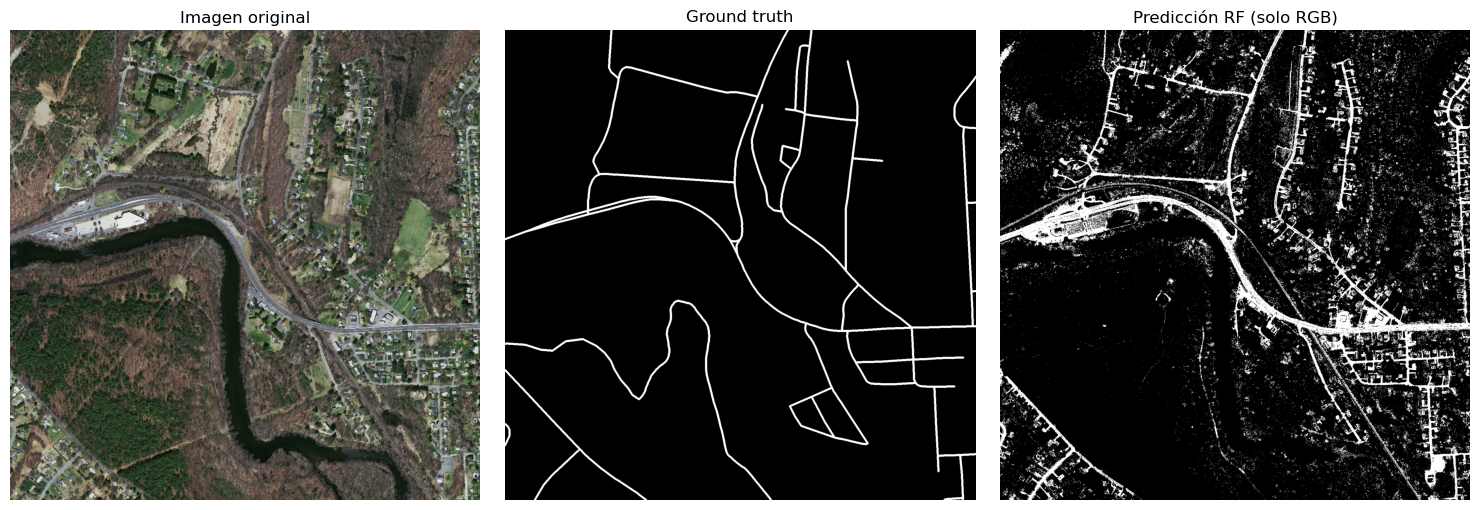

In [11]:
# RANDOM FOREST
# Definimos el modelo.
rf_raw = RandomForestClassifier(n_estimators= 200, max_depth= 20,  min_samples_leaf=5, random_state=seed, n_jobs=-1, verbose= 1)

# Lo entrenamos 
rf_raw, y_val_pred, y_test_pred, metrics_val, metrics_test = train_and_evaluate_model(rf_raw, X_train_flat, y_train_flat,X_val_flat, y_val_flat, 
                                                                                                      X_test_flat, y_test_flat, model_name="RandomForest RGB")
# Guardamos los resultados y visualizamos 
resultados.append(("RandomForest", metrics_val, metrics_test))
show_example_prediction(X_val, y_val, y_val_pred, title="Predicción RF (solo RGB)")


=== LogisticRegression RGB: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8252
  Precision: 0.2268
  Recall:    0.7460
  F1-Score:  0.3478
  Jaccard:   0.2105
  Dice:      0.3478

=== TEST ===

Test:
  Accuracy:  0.8292
  Precision: 0.1147
  Recall:    0.8029
  F1-Score:  0.2007
  Jaccard:   0.1115
  Dice:      0.2007


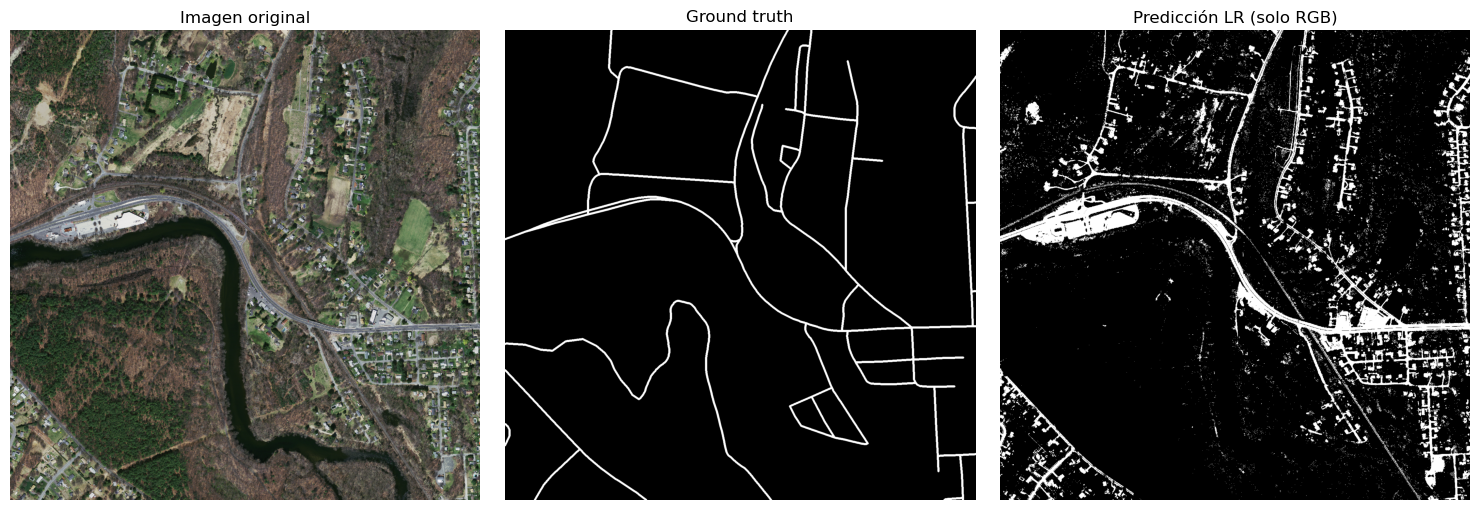

In [12]:
# LOGISTIC REGRESSION
lr_raw = LogisticRegression(C=10, max_iter=500, random_state=seed)

# Lo entrenamos 
lr_raw, y_val_pred, y_test_pred, metrics_val, metrics_test = train_and_evaluate_model(lr_raw, X_train_flat, y_train_flat,X_val_flat, y_val_flat, 
                                                                                                      X_test_flat, y_test_flat, model_name="LogisticRegression RGB")
# Visualizamos 
resultados.append(("LogisticRegression", metrics_val, metrics_test))
show_example_prediction(X_val, y_val, y_val_pred, title="Predicción LR (solo RGB)")


=== KNN RGB: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8097
  Precision: 0.2149
  Recall:    0.7709
  F1-Score:  0.3361
  Jaccard:   0.2020
  Dice:      0.3361

=== TEST ===

Test:
  Accuracy:  0.8203
  Precision: 0.1124
  Recall:    0.8305
  F1-Score:  0.1980
  Jaccard:   0.1098
  Dice:      0.1980


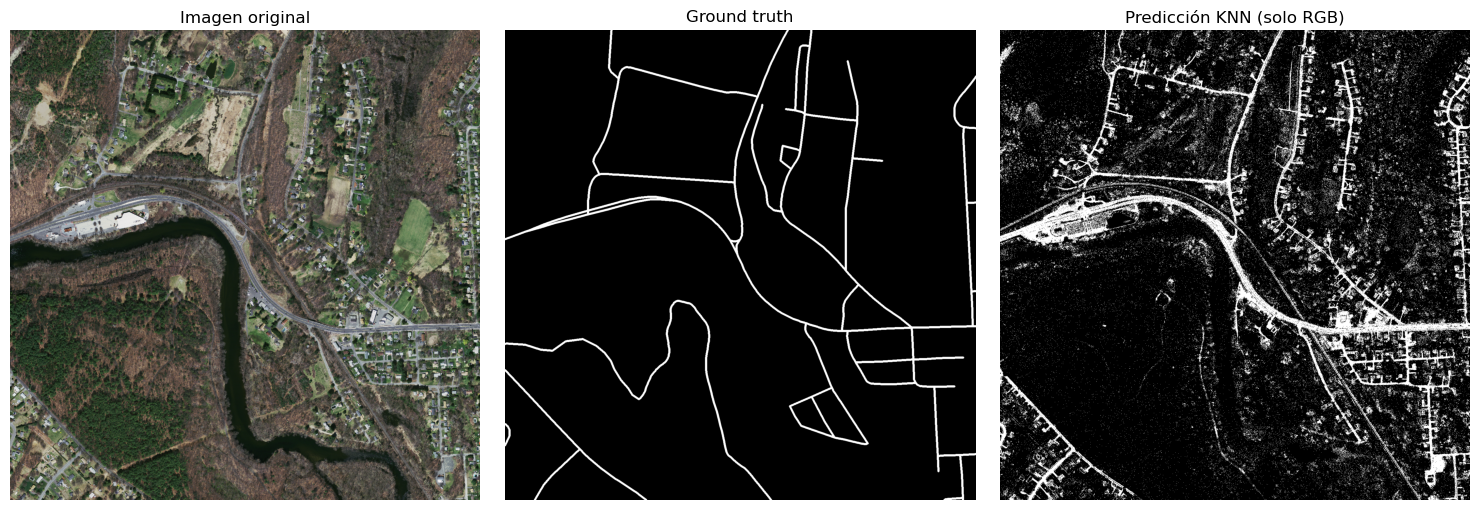

In [13]:
# K NEAREST NEIGHBOURS
knn_raw = KNeighborsClassifier(n_neighbors=5)

# Lo entrenamos 
knn_raw, y_val_pred, y_test_pred, metrics_val, metrics_test = train_and_evaluate_model(knn_raw, X_train_flat, y_train_flat,X_val_flat, y_val_flat, 
                                                                                                      X_test_flat, y_test_flat, model_name="KNN RGB")
# Visualizamos 
resultados.append(("KNN", metrics_val, metrics_test))
show_example_prediction(X_val, y_val, y_val_pred, title="Predicción KNN (solo RGB)")


=== Decision Tree RGB: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8240
  Precision: 0.2310
  Recall:    0.7804
  F1-Score:  0.3565
  Jaccard:   0.2169
  Dice:      0.3565

=== TEST ===

Test:
  Accuracy:  0.8328
  Precision: 0.1210
  Recall:    0.8400
  F1-Score:  0.2115
  Jaccard:   0.1183
  Dice:      0.2115


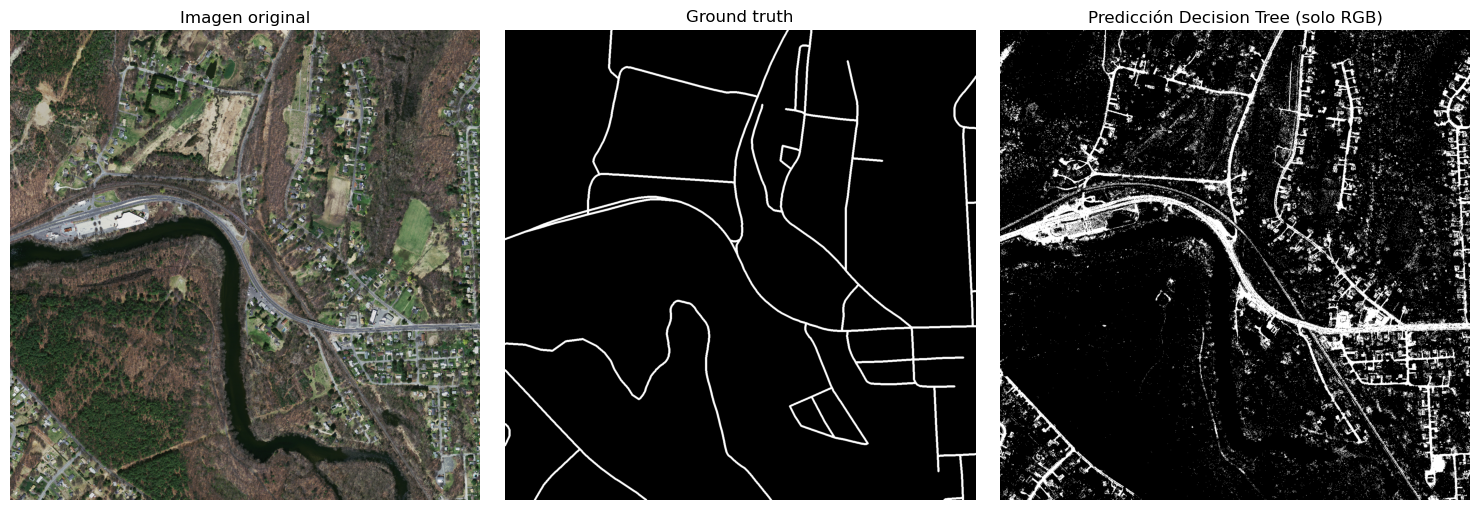

In [14]:
# DECISION TREE
dt_raw = DecisionTreeClassifier(max_depth= 15, min_samples_split=10, min_samples_leaf=5, criterion="gini", random_state = seed)

# Lo entrenamos 
dt_raw, y_val_pred, y_test_pred, metrics_val, metrics_test = train_and_evaluate_model(dt_raw, X_train_flat, y_train_flat,X_val_flat, y_val_flat, 
                                                                                                      X_test_flat, y_test_flat, model_name="Decision Tree RGB")
# Visualizamos 
resultados.append(("DecisionTree", metrics_val, metrics_test))
show_example_prediction(X_val, y_val, y_val_pred, title="Predicción Decision Tree (solo RGB)")


=== SVM RGB: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...
Modelo entrenado

=== VALIDACIÓN ===

Validación:
  Accuracy:  0.8290
  Precision: 0.2295
  Recall:    0.7362
  F1-Score:  0.3499
  Jaccard:   0.2121
  Dice:      0.3499

=== TEST ===

Test:
  Accuracy:  0.8308
  Precision: 0.1148
  Recall:    0.7954
  F1-Score:  0.2007
  Jaccard:   0.1115
  Dice:      0.2007


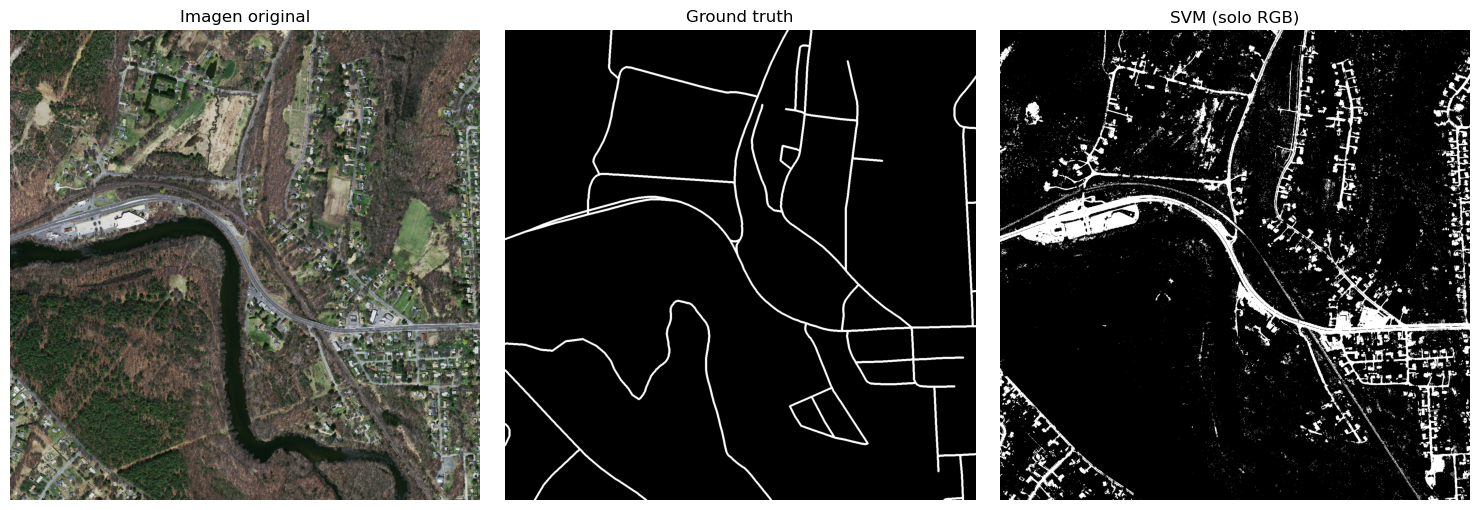

In [15]:
svm_raw = LinearSVC(C=1, max_iter=2000, random_state=seed)

# Lo entrenamos 
svm_raw, y_val_pred, y_test_pred, metrics_val, metrics_test = train_and_evaluate_model(svm_raw, X_train_flat, y_train_flat,X_val_flat, y_val_flat, 
                                                                                                      X_test_flat, y_test_flat, model_name="SVM RGB")
# Visualizamos 
resultados.append(("SVM", metrics_val, metrics_test))
show_example_prediction(X_val, y_val, y_val_pred, title="SVM (solo RGB)")

##### Tabla comparativa 

probé tb con gradient boosting y tardaba una barbaridad... me lo cargué lmao

In [16]:
resultados = list({m[0]: m for m in resultados}.values())
def comparar_modelos(resultados):
    """
    resultados = lista de tuplas:
       (nombre_modelo, metrics_val, metrics_test)
    """
    filas = []

    for nombre, mval, mtest in resultados:
        fila = {
            "Modelo": nombre,
            "Val_Acc": mval["acc"],
            "Val_Prec": mval["prec"],
            "Val_Rec": mval["rec"],
            "Val_F1": mval["f1"],
            "Val_Jaccard": mval["jaccard"],
            "Val_Dice": mval["dice"],
            "Test_Acc": mtest["acc"],
            "Test_Prec": mtest["prec"],
            "Test_Rec": mtest["rec"],
            "Test_F1": mtest["f1"],
            "Test_Jaccard": mtest["jaccard"],
            "Test_Dice": mtest["dice"],
        }
        filas.append(fila)

    df = pd.DataFrame(filas).sort_values(by="Val_Dice", ascending=False)
    display(df)
    return df
    
df_comparativa = comparar_modelos(resultados)


,Modelo,Val_Acc,Val_Prec,Val_Rec,Val_F1,Val_Jaccard,Val_Dice,Test_Acc,Test_Prec,Test_Rec,Test_F1,Test_Jaccard,Test_Dice
0,RandomForest,0.825016,0.232548,0.782537,0.358546,0.218432,0.358546,0.833044,0.121283,0.840995,0.211993,0.118564,0.211993
3,DecisionTree,0.823952,0.231039,0.780414,0.356529,0.216937,0.356529,0.832771,0.120990,0.839955,0.211513,0.118264,0.211513
4,SVM,0.829047,0.229492,0.736172,0.349905,0.212052,0.349905,0.830803,0.114824,0.795366,0.200677,0.111529,0.200677
1,LogisticRegression,0.825185,0.226790,0.745961,0.347832,0.210530,0.347832,0.829211,0.114672,0.802873,0.200681,0.111532,0.200681
2,KNN,0.809700,0.214920,0.770885,0.336129,0.202016,0.336129,0.820295,0.112368,0.830468,0.197953,0.109849,0.197953


### Prueba con más características 

In [ ]:
X_train_col_flat, y_train_col_flat  = prepare_pixel_dataset(X_train, y_train, feature_type="color", balance_train=True)
print_dataset_info(X_train, y_train, X_train_col_flat, y_train_col_flat, "Train")

X_val_col_flat, y_val_col_flat = prepare_pixel_dataset(X_val, y_val, feature_type="color", balance_train=False)
print_dataset_info(X_val, y_val, X_val_col_flat, y_val_col_flat, "Validación")

X_test_col_flat,  y_test_col_flat = prepare_pixel_dataset(X_test, y_test, feature_type="color", balance_train=False)
print_dataset_info(X_test, y_test, X_test_col_flat, y_test_col_flat, "Test")

resultados2 = []

In [ ]:
# RANDOM FOREST
# Definimos el modelo.
rf_col = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=seed, n_jobs=-1, verbose=1)
# Lo entrenamos 
rf_col, y_val_pred_col, y_test_pred_col, metrics_val_col, metrics_test_col = train_and_evaluate_model(rf_col, X_train_col_flat, y_train_col_flat, X_val_col_flat, y_val_col_flat, 
                                                                                                      X_test_col_flat, y_test_col_flat, model_name="RandomForest Features")
# Guardamos los resultados y visualizamos 
resultados2.append(("Random Forest", metrics_val_col, metrics_test_col))
show_example_prediction(X_val, y_val, y_val_pred_col, title="Predicción RF (features extendido)")

In [ ]:
# DECISION TREE
dt_col = DecisionTreeClassifier(max_depth= 15, min_samples_split=10, min_samples_leaf=5, criterion="gini", random_state = seed)

# Lo entrenamos 
dt_col, y_val_pred_col, y_test_pred_col, metrics_val_col, metrics_test_col = train_and_evaluate_model(dt_col, X_train_col_flat, y_train_col_flat,X_val_col_flat, y_val_col_flat, 
                                                                                                      X_test_col_flat, y_test_col_flat, model_name="Decision Tree Features")
# Visualizamos 
# Visualizamos 
resultados2.append(("DecisionTree", metrics_val, metrics_test))
show_example_prediction(X_val, y_val, y_val_pred, title="Predicción Decision Tree (features extendido)")

In [ ]:
svm_col = LinearSVC(C=1, max_iter=2000, random_state=seed)

# Lo entrenamos 
svm_col, y_val_pred_col, y_test_pred_col, metrics_val_col, metrics_test_col = train_and_evaluate_model(svm_col, X_train_col_flat, y_train_col_flat,X_val_col_flat, y_val_col_flat, 
                                                                                                      X_test_col_flat, y_test_col_flat, model_name="SVM Features")
# Visualizamos 
resultados2.append(("SVM", metrics_val_col, metrics_test_col))
show_example_prediction(X_val, y_val, y_val_pred_col, title="SVM (features extendido)")

In [ ]:
df_comparativa = comparar_modelos(resultados2)

### Postprocesado (le pedi al amigo q me aplicara tu funcion, no me paré para mirar nada pero todo lo anterior yes)

In [118]:
# habria que cambiarlo un poco me parece muy agresivo ??????
def postprocesar_mascara(mascara_pred):
    from skimage.morphology import (binary_opening, binary_closing, 
                                     disk, remove_small_objects, 
                                     remove_small_holes)
    
    mascara = mascara_pred.astype(bool)

    # Paso 1: Opening moderado para eliminar ruido disperso
    mascara = binary_opening(mascara, disk(3))  # Reducido de 4 a 3
    
    # Paso 2: Closing moderado para conectar carreteras cercanas
    mascara = binary_closing(mascara, disk(5))  # Reducido de 8 a 6
    
    # Paso 3: Eliminar objetos pequeños (valor intermedio)
    mascara = remove_small_objects(mascara, min_size=400)  # Reducido de 800 a 400
        
    # Paso 5: Suavizado final ligero
    mascara = binary_opening(mascara, disk(1))  # Reducido de 2 a 1
    
    return mascara.astype(np.uint8)

In [119]:
# Reconvertimos predicciones planas a imágenes
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
y_test_pred_img = y_test_pred.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

y_val_post = np.zeros_like(y_val_pred_img, dtype=np.uint8)
y_test_post = np.zeros_like(y_test_pred_img, dtype=np.uint8)

# Procesar validación
for i in range(X_val.shape[0]):
    y_val_post[i] = postprocesar_mascara(y_val_pred_img[i])

# Procesar test
for i in range(X_test.shape[0]):
    y_test_post[i] = postprocesar_mascara(y_test_pred_img[i])


# EVALUACIÓN

# Aplanar
y_val_post_flat = y_val_post.reshape(-1)
y_test_post_flat = y_test_post.reshape(-1)

print("\n=== VALIDACIÓN (postprocesado) ===")
acc_p  = accuracy_score(y_val_flat,  y_val_post_flat)
prec_p = precision_score(y_val_flat, y_val_post_flat)
rec_p  = recall_score(y_val_flat,   y_val_post_flat)
f1_p   = f1_score(y_val_flat,       y_val_post_flat)

print(f"Accuracy:  {acc_p:.4f}")
print(f"Precision: {prec_p:.4f}")
print(f"Recall:    {rec_p:.4f}")
print(f"F1-Score:  {f1_p:.4f}")


print("\n=== TEST (postprocesado) ===")
acc_tp  = accuracy_score(y_test_flat,  y_test_post_flat)
prec_tp = precision_score(y_test_flat, y_test_post_flat)
rec_tp  = recall_score(y_test_flat,   y_test_post_flat)
f1_tp   = f1_score(y_test_flat,       y_test_post_flat)

print(f"Accuracy:  {acc_tp:.4f}")
print(f"Precision: {prec_tp:.4f}")
print(f"Recall:    {rec_tp:.4f}")
print(f"F1-Score:  {f1_tp:.4f}")


=== VALIDACIÓN (postprocesado) ===
Accuracy:  0.9152
Precision: 0.4025
Recall:    0.7359
F1-Score:  0.5204

=== TEST (postprocesado) ===
Accuracy:  0.8769
Precision: 0.1569
Recall:    0.8260
F1-Score:  0.2638


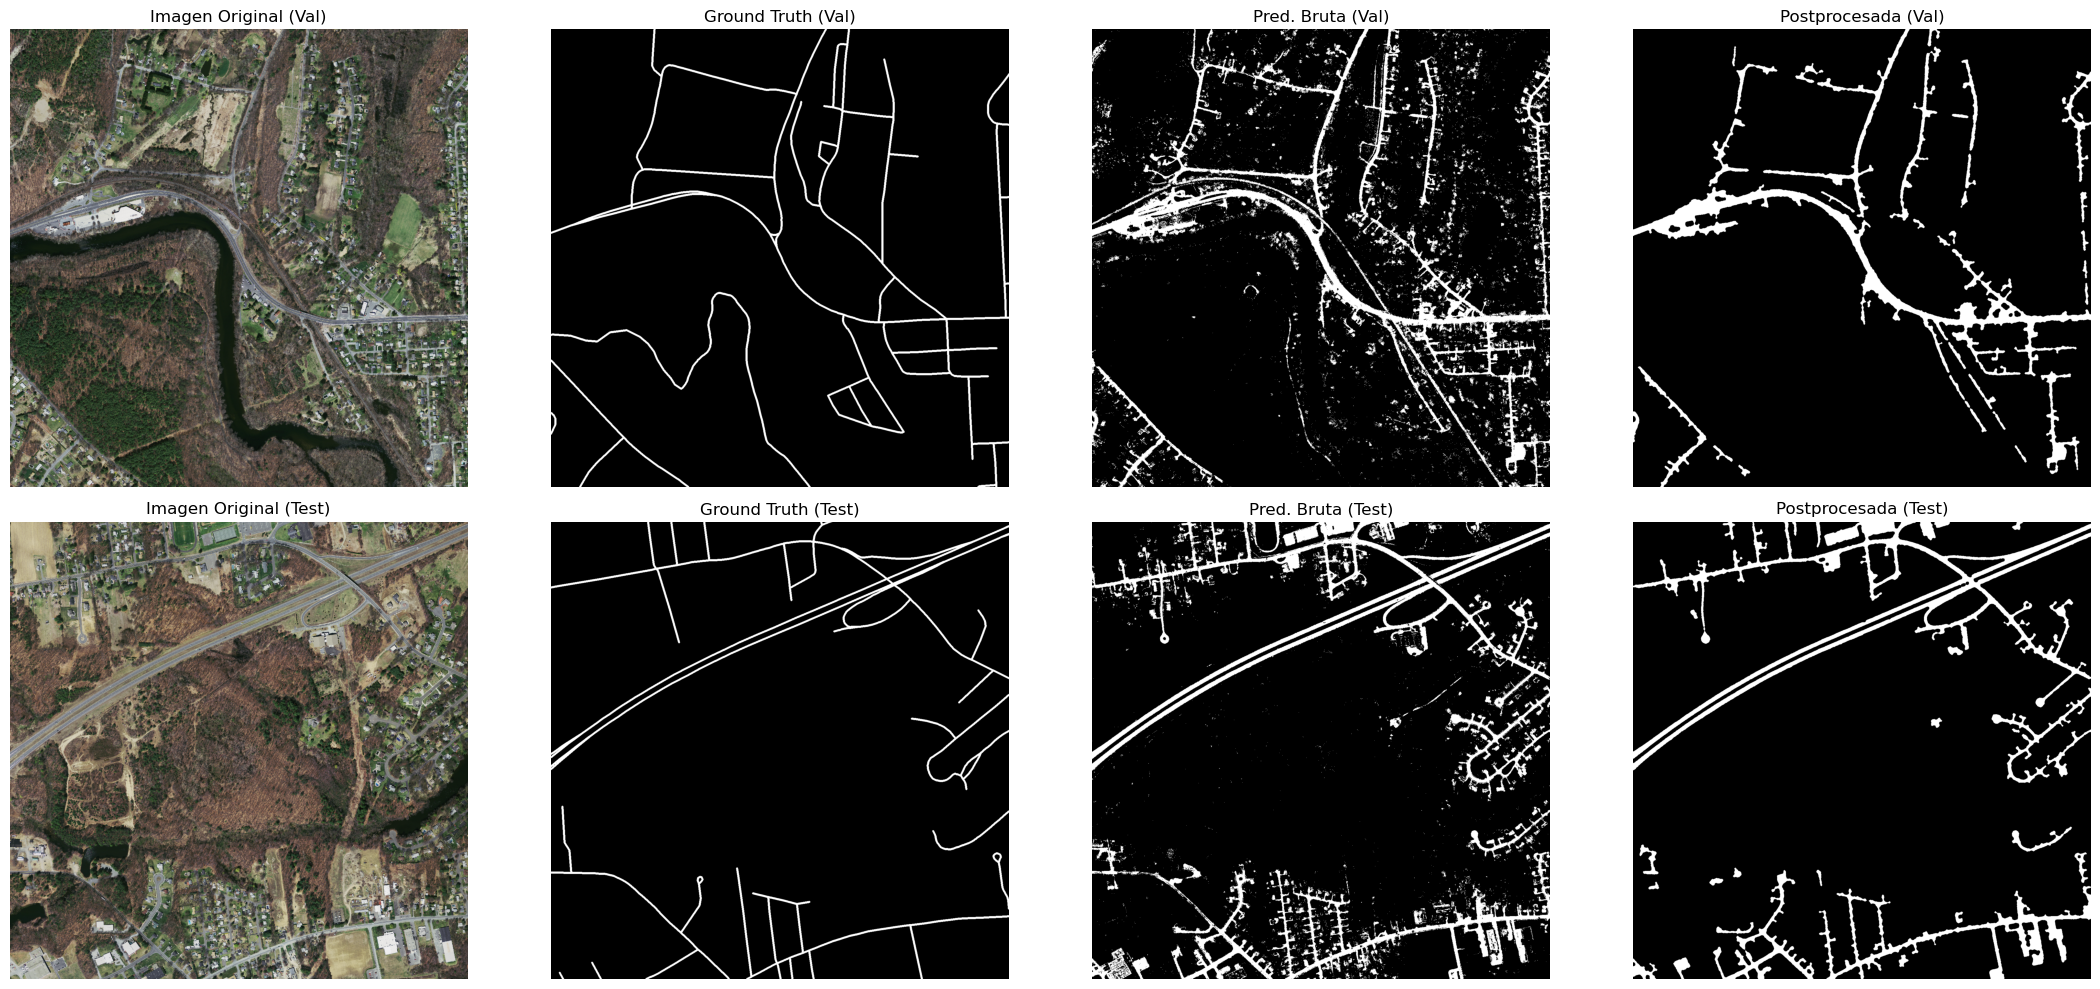

In [120]:

idx_val = 0  # índice de imagen de validación
idx_test = 0 # índice de imagen de test

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# ---- VALIDACIÓN ----
axes[0,0].imshow(X_val[idx_val])
axes[0,0].set_title("Imagen Original (Val)")
axes[0,0].axis('off')

axes[0,1].imshow(y_val[idx_val], cmap='gray')
axes[0,1].set_title("Ground Truth (Val)")
axes[0,1].axis('off')

axes[0,2].imshow(y_val_pred_img[idx_val], cmap='gray')
axes[0,2].set_title("Pred. Bruta (Val)")
axes[0,2].axis('off')

axes[0,3].imshow(y_val_post[idx_val], cmap='gray')
axes[0,3].set_title("Postprocesada (Val)")
axes[0,3].axis('off')


# ---- TEST ----
axes[1,0].imshow(X_test[idx_test])
axes[1,0].set_title("Imagen Original (Test)")
axes[1,0].axis('off')

axes[1,1].imshow(y_test[idx_test], cmap='gray')
axes[1,1].set_title("Ground Truth (Test)")
axes[1,1].axis('off')

axes[1,2].imshow(y_test_pred_img[idx_test], cmap='gray')
axes[1,2].set_title("Pred. Bruta (Test)")
axes[1,2].axis('off')

axes[1,3].imshow(y_test_post[idx_test], cmap='gray')
axes[1,3].set_title("Postprocesada (Test)")
axes[1,3].axis('off')

plt.tight_layout()
plt.show()

